# 567. Permutation in String

Given two strings s1 and s2, return true if s2 contains a permutation of s1, or false otherwise.

In other words, return true if one of s1's permutations is the substring of s2.

## Example 1:

Input: s1 = "ab", s2 = "eidbaooo"
Output: true
Explanation: s2 contains one permutation of s1 ("ba").

## Example 2:

Input: s1 = "ab", s2 = "eidboaoo"
Output: false
 
Constraints:

1 <= s1.length, s2.length <= 104
s1 and s2 consist of lowercase English letters.

## Specification


Temos duas strings s1 e s2 dadas como parâmetro.
Precisamos retornar True se existe uma substring de s2 que seja uma permutação de s1 (ou seja, um anagrama de s1), e False caso contrário.
Edge cases

Se len(s1) > len(s2), retornamos False (não cabe uma permutação).
Se len(s1) == len(s2), basta verificar se são anagramas.
Se s1 == s2, retornamos True.
Plan


Vamos visualizar com um exemplo:

s1 = 'a b a c' (tamanho 4)
s2 = 'h a b c d a a c a s b a c a'
A ideia é usar uma janela deslizante (sliding window) de tamanho igual a s1 sobre s2:


'h a b c d a a c a s b a c a' L     R
A janela começa em left = 0, right = 3 (tamanho 4).
Pegamos a substring s2[left:right+1] e verificamos se é anagrama de s1.
A cada passo:

Andamos a janela para frente: left += 1, right += 1
Pegamos a próxima substring de tamanho 4 e repetimos a verificação.
Fazemos isso até o final de s2, ou seja, até right == len(s2) - 1.

Quantas janelas vamos testar?
O número de janelas é len(s2) - len(s1) + 1
Exemplo: se len(s2) = 7 e len(s1) = 4, teremos 7 - 4 + 1 = 4 janelas para testar.
Por que essa conta?
Porque a última janela possível começa em left = len(s2) - len(s1)
Se começarmos depois disso, a janela ficaria menor que s1 e não faria sentido comparar.
Resumindo
Para cada posição possível, pegamos uma substring de tamanho igual a s1 e verificamos se é anagrama.
Se encontrar, retorna True.
Se terminar todas as janelas e não encontrar, retorna False.
Se quiser, posso detalhar como otimizar a verificação de anagrama usando dicionários de frequência!



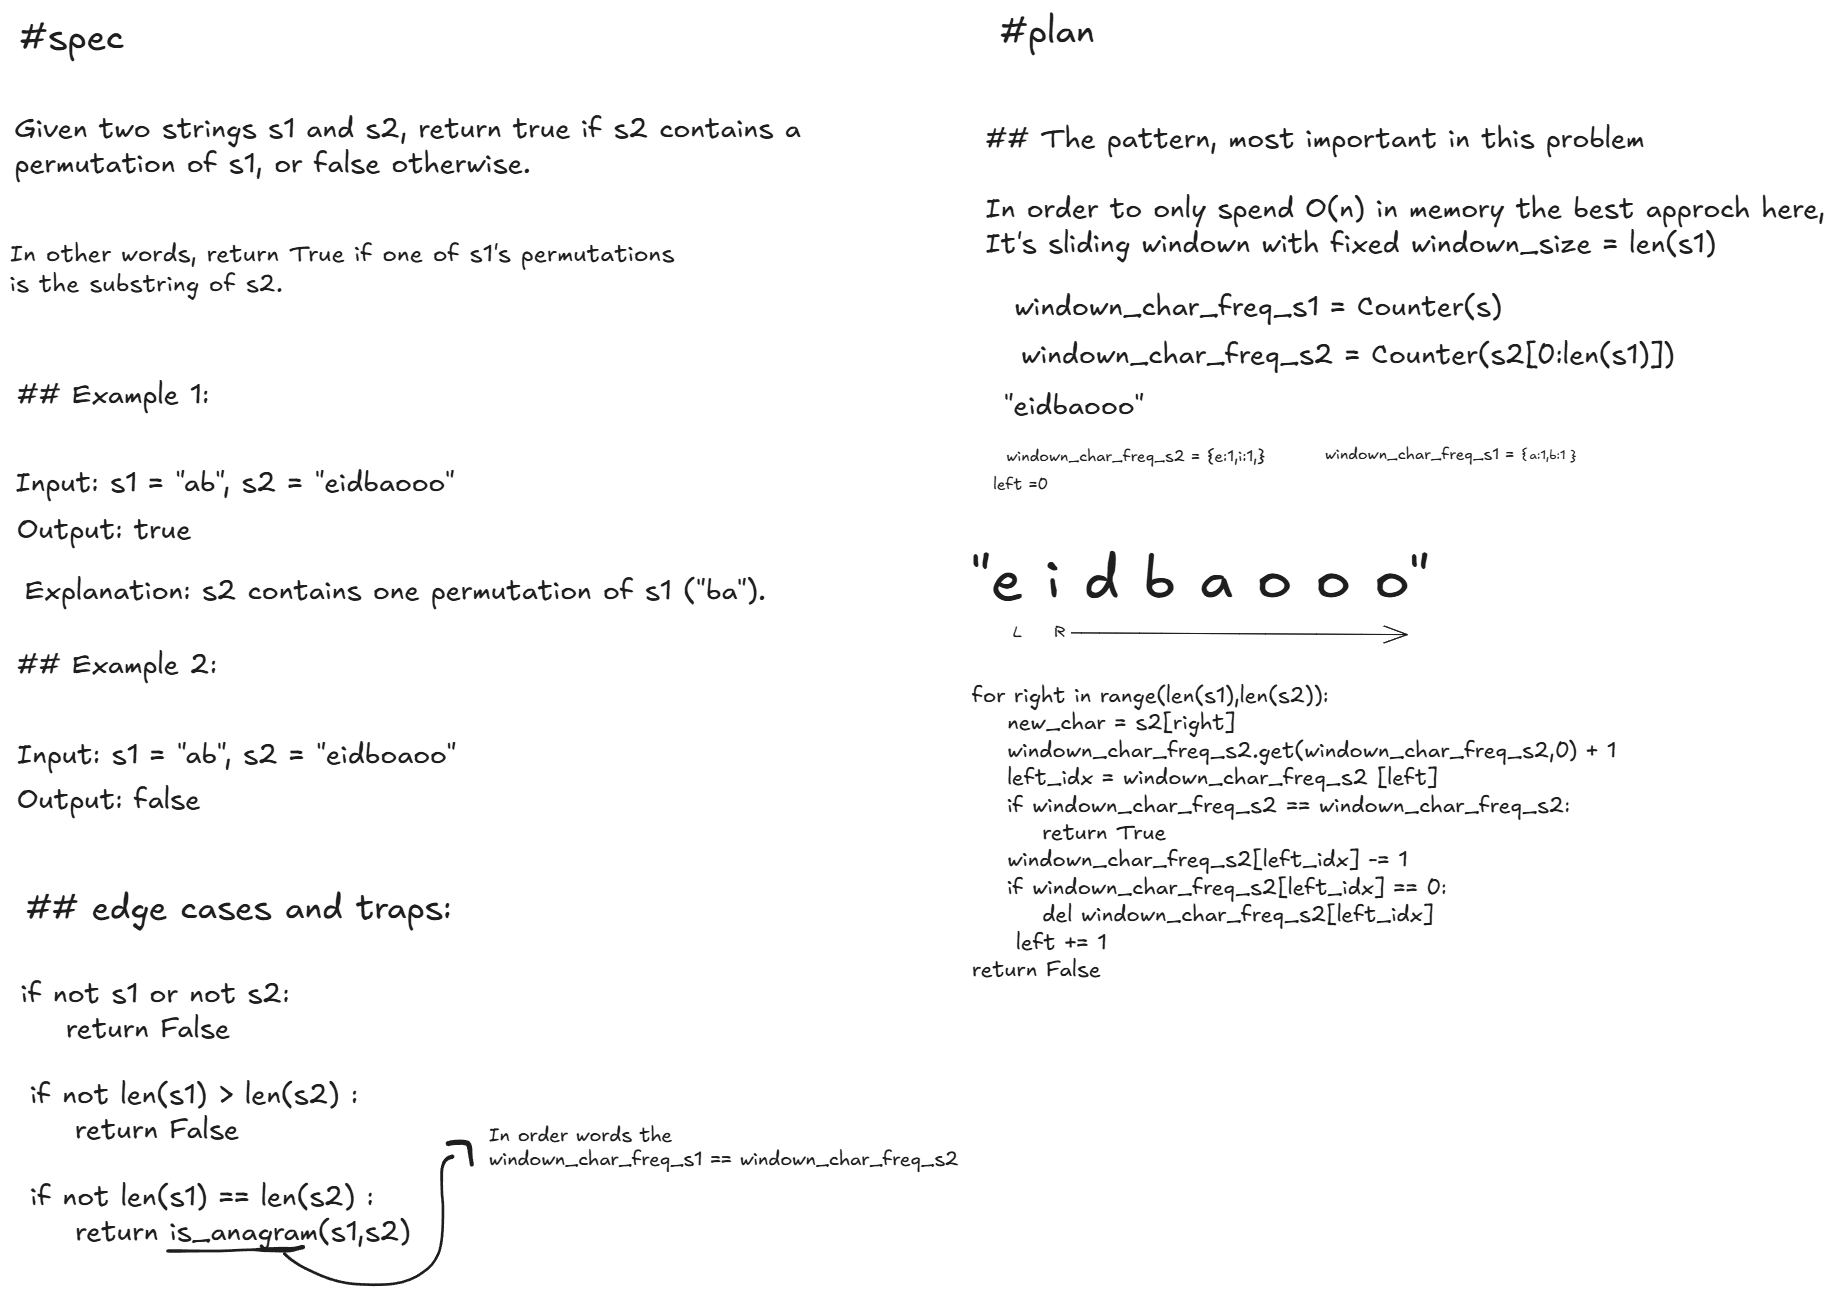

In [ ]:
from collections import Counter
class Solution:
    def checkInclusion(self, s1: str, s2: str) -> bool:
        if len(s1) > len(s2):
            return False
        s1_count = Counter(s1)
        window_count = Counter(s2[:len(s1)])
        if window_count == s1_count:
            return True
        for i in range(len(s1), len(s2)):
            window_count[s2[i]] += 1
            window_count[s2[i - len(s1)]] -= 1 #Final da janela que sai
            if window_count[s2[i - len(s1)]] == 0:
                del window_count[s2[i - len(s1)]]
            if window_count == s1_count:
                return True
        return False

In [ ]:
# Cliente para testar a solução

s1 = "ab"
s2 = "eidbaooo"
sol = Solution()
print(f"Entrada: s1 = {s1}, s2 = {s2}")
print("Saída esperada: True")
print("Saída obtida:", sol.checkInclusion(s1, s2))
print()

s1 = "ab"
s2 = "eidboaoo"
print(f"Entrada: s1 = {s1}, s2 = {s2}")
print("Saída esperada: False")
print("Saída obtida:", sol.checkInclusion(s1, s2))
print()

s1 = "aabc"
s2 = "habcdaacbasbaca"
print(f"Entrada: s1 = {s1}, s2 = {s2}")
print("Saída esperada: True")
print("Saída obtida:", sol.checkInclusion(s1, s2))